# 사출성형 공정데이터 기반 품질불량 사전예측 및 검사 우선순위 결정

| 장 | 내용 |
|---|---|
| 1 | 데이터 이해 및 진단 |
| 2 | AI 예측모델 개발 및 성능평가 |
| 3 | 영향요인 및 오류분석 |
| 4 | 현장 활용방안 (검사 우선순위) |

모든 로직은 `src/` 모듈에 있으며, 이 노트북은 그 함수를 불러 결과를 시각화한다.
전체 파이프라인은 `python run_all.py` 로도 동일하게 실행된다.

## 0. 환경 설정

In [82]:
import json
import warnings
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone

from src.config import INDEX_COL, OUT_DIR, SEED, TARGET
from src.data import diagnose, feature_matrix, load_all, load_labeled, process_cols, scaling_check
from src.evaluate import best_threshold, inner_oof, metrics
from src.models import get_models
from run_all import holdout_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")          # seaborn 스타일을 먼저 적용하고
plt.rcParams["font.family"] = {     # 그 다음에 한글 폰트를 지정
    "Windows": "Malgun Gothic",
    "Darwin": "AppleGothic",        # Mac
}.get(platform.system(), "NanumGothic")
plt.rcParams["axes.unicode_minus"] = False   # 음수 기호(-) 깨짐 방지

In [84]:
# CV 결과가 없으면 전체 파이프라인을 먼저 실행 (CPU 약 10분)
if not (OUT_DIR / "cv_folds.csv").exists():
    import run_all
    run_all.main()

## 1. 데이터 이해 및 진단

In [87]:
df = load_all()
FEATS = process_cols(load_labeled("cn7"))
print("행 수:", len(df), "/ 공정변수:", len(FEATS))
df.head()

행 수: 2393 / 공정변수: 24


,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,shot_id,cavity,shot_size,product,group
0,0,0,1.679123,1.491397,-0.478017,0.361047,0.97858,-0.711164,1.532018,0.0,-1.152398,-0.795730,-0.132022,0.63521,1.256518,-0.916676,-0.533773,0.729073,-1.598068,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574,-1,0,1,cn7,cn7_-1
1,1,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0.0,-1.347095,0.049553,-0.132022,0.63521,1.573231,-0.740752,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339,0,0,2,cn7,cn7_0
2,2,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0.0,-1.347095,0.049553,-0.132022,0.63521,1.573231,-0.740752,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339,0,1,2,cn7,cn7_0
3,3,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0.0,-1.347095,1.740153,-0.132022,0.63521,1.256518,-0.740752,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339,1,0,2,cn7,cn7_1
4,4,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0.0,-1.347095,1.740153,-0.132022,0.63521,1.256518,-0.740752,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339,1,1,2,cn7,cn7_1


In [88]:
diag = diagnose(df)
diag.T

,0,1
product,cn7,rg3
rows,1211,1182
fail_rows,17,25
fail_rate,0.014038,0.021151
missing,0,0
constant_cols,Clamp_Open_Position,Clamp_Open_Position
shots,641,608
shots_2cavity,570,574
fail_shots,14,25
fail_at_cavity0,13,23


### 1-1. 클래스 불균형

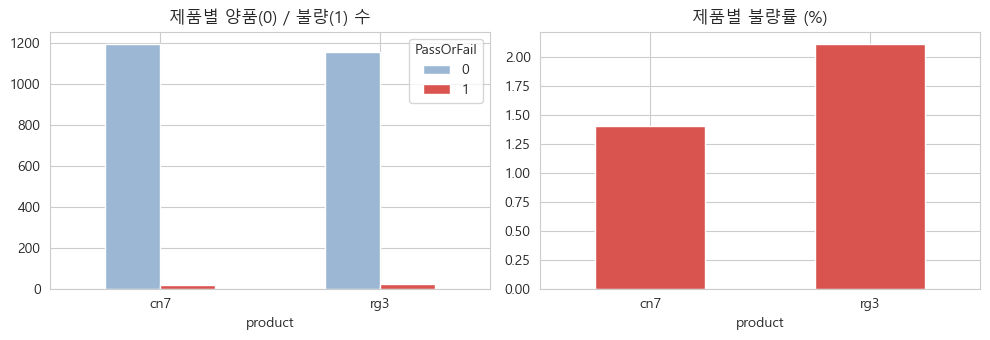

In [92]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
cnt = df.groupby(["product", TARGET]).size().unstack()
cnt.plot.bar(ax=ax[0], rot=0, color=["#9bb7d4", "#d9534f"])
ax[0].set_title("제품별 양품(0) / 불량(1) 수")
(df.groupby("product")[TARGET].mean() * 100).plot.bar(ax=ax[1], rot=0, color="#d9534f")
ax[1].set_title("제품별 불량률 (%)")
plt.tight_layout(); plt.show()

### 1-2. 2캐비티 사출 구조
공정값이 동일한 연속 2행 = 한 번의 사출(shot)에서 나온 제품 2개.
→ 같은 사출이 학습/검증에 나뉘면 정답이 새므로 **사출 단위 그룹 CV** 를 사용한다.

In [94]:
shot_tbl = (df.groupby("product")
              .apply(lambda d: pd.Series({
                  "사출 수": d.shot_id.nunique(),
                  "2개 제품 사출": (d.groupby("shot_id").size() == 2).sum(),
                  "1개 제품 사출": (d.groupby("shot_id").size() == 1).sum(),
                  "불량 사출": (d.groupby("shot_id")[TARGET].sum() > 0).sum(),
              })))
display(shot_tbl)

cav = pd.crosstab([df["product"], df["cavity"]], df[TARGET], margins=False)
cav["불량률(%)"] = (cav[1] / cav.sum(axis=1) * 100).round(2)
display(cav)

,사출 수,2개 제품 사출,1개 제품 사출,불량 사출
product,,,,
cn7,641,570,71,14
rg3,608,574,34,25


PassOrFail        0   1  불량률(%)
product cavity                 
cn7     0       628  13    2.03
        1       566   4    0.70
rg3     0       585  23    3.78
        1       572   2    0.35

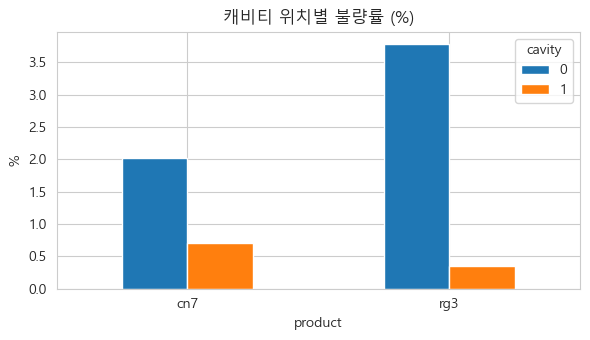

In [95]:
fig, ax = plt.subplots(figsize=(6, 3.5))
(df.groupby(["product", "cavity"])[TARGET].mean() * 100).unstack().plot.bar(ax=ax, rot=0)
ax.set_title("캐비티 위치별 불량률 (%)"); ax.set_ylabel("%")
plt.tight_layout(); plt.show()

### 1-3. 라벨 충돌 (공정값만으로 구분 불가능한 불량)
같은 공정값 패턴 안에 양품과 불량이 함께 존재하는 경우 → 공정변수만으로는 이론적으로 구분할 수 없다.

In [99]:
rows = []
for p, d in df.groupby("product"):
    pat = d.groupby(FEATS)[TARGET].agg(["size", "nunique", "sum"])
    rows.append({"product": p,
                 "불량 수": int(d[TARGET].sum()),
                 "충돌 패턴 내 불량": int(pat.loc[pat["nunique"] > 1, "sum"].sum()),
                 "순수 불량 패턴": int((pat["sum"] == pat["size"]).sum())})
pd.DataFrame(rows)

,product,불량 수,충돌 패턴 내 불량,순수 불량 패턴
0,cn7,17,11,3
1,rg3,25,25,0


### 1-4. 결측·상수·스케일 점검

In [102]:
print("결측치 합계:", int(df[FEATS].isna().sum().sum()))
print("상수 컬럼:", [c for c in FEATS if df[c].nunique() == 1])
scaling_check()   # 라벨/비라벨 데이터가 각자 따로 표준화됨 → 결합하지 않음

결측치 합계: 0
상수 컬럼: ['Clamp_Open_Position']


,product,set,rows,max_abs_mean,min_std,max_std
0,cn7,labeled,1211,4.630532e-12,0.000000,1.000413
1,cn7,unlabeled,35239,9.872066e-15,1.000014,1.000014
2,rg3,labeled,1182,2.788886e-12,0.000000,1.000423
3,rg3,unlabeled,35941,7.072807e-15,1.000014,1.000014


### 1-5. 시간(생산 순번)에 따른 불량 분포

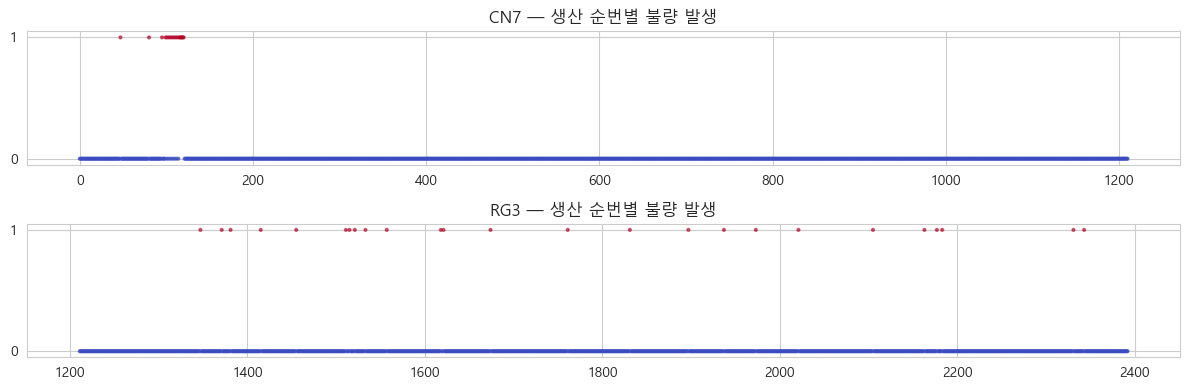

In [105]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharey=True)
for ax, (p, d) in zip(axes, df.groupby("product")):
    ax.scatter(d[INDEX_COL], d[TARGET], s=4, alpha=.6, c=d[TARGET], cmap="coolwarm")
    ax.set_title(f"{p.upper()} — 생산 순번별 불량 발생"); ax.set_yticks([0, 1])
plt.tight_layout(); plt.show()

### 1-6. 양품 vs 불량 공정변수 분포

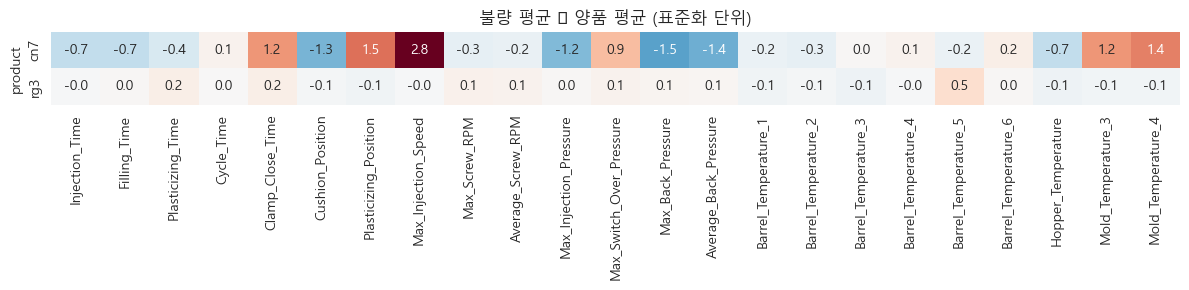

In [107]:
use = [c for c in FEATS if df[c].nunique() > 1]
diff = (df.groupby(["product", TARGET])[use].mean()
          .groupby(level=0).diff().dropna().droplevel(1))
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(diff, cmap="RdBu_r", center=0, annot=True, fmt=".1f", ax=ax, cbar=False)
ax.set_title("불량 평균 − 양품 평균 (표준화 단위)")
plt.tight_layout(); plt.show()

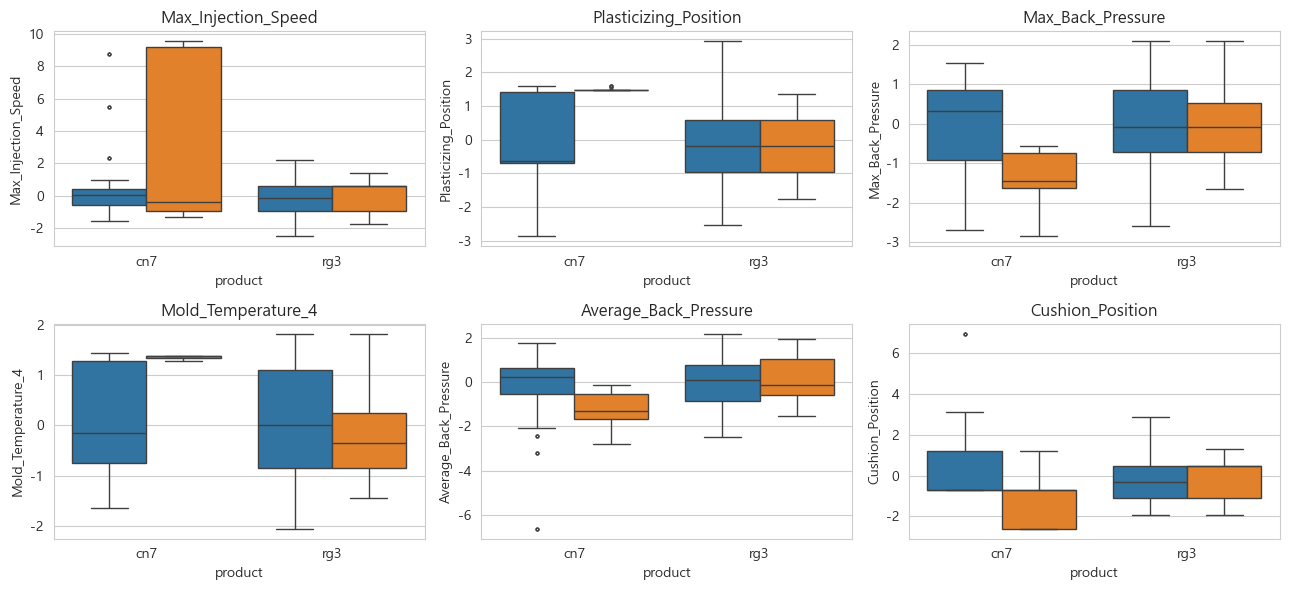

In [108]:
top = diff.abs().max().sort_values(ascending=False).index[:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, c in zip(axes.ravel(), top):
    sns.boxplot(data=df, x="product", y=c, hue=TARGET, ax=ax, fliersize=2)
    ax.set_title(c); ax.legend_.remove()
plt.tight_layout(); plt.show()

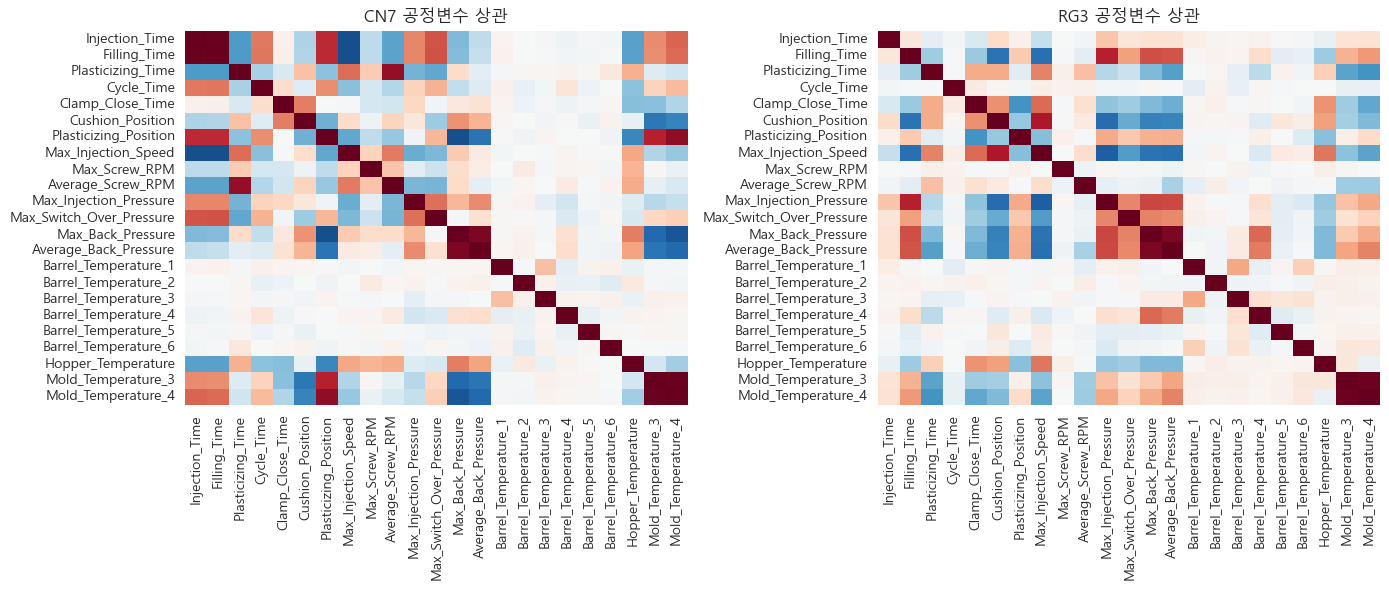

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (p, d) in zip(axes, df.groupby("product")):
    sns.heatmap(d[use].corr(), cmap="RdBu_r", center=0, ax=ax, cbar=False)
    ax.set_title(f"{p.upper()} 공정변수 상관")
plt.tight_layout(); plt.show()

## 2. AI 예측모델 개발 및 성능평가
- 개발/테스트: 사출 단위·불량 층화로 80/20 분리 (테스트는 모델·임계값 선정에 미사용)
- 개발셋에서 **반복 StratifiedGroupKFold (5-fold × 5회)**
- 비교: 모델 3종 (LR 베이스라인, RandomForest, LightGBM) × 특성셋 2종 (공정변수만 / +캐비티)
- 주지표 PR-AUC, 보조지표 F1 · Recall@상위k%

In [111]:
cv = pd.read_csv(OUT_DIR / "cv_folds.csv")
MET = ["PR_AUC", "ROC_AUC", "F1", "Precision", "Recall", "Recall@5%", "Recall@10%", "Recall@20%"]
summary = cv.groupby(["scope", "features", "model"])[MET].agg(["mean", "std"]).round(3)
summary.loc["all"]

PR_AUC        ROC_AUC            F1        Precision        Recall        Recall@5%        Recall@10%        Recall@20%       
                              mean    std    mean    std   mean    std      mean    std   mean    std      mean    std       mean    std       mean    std
features       model                                                                                                                                      
process+cavity LR_baseline   0.109  0.092   0.768  0.119  0.089  0.100     0.060  0.077  0.278  0.286     0.209  0.181      0.348  0.214      0.512  0.248
               LightGBM      0.110  0.106   0.792  0.066  0.085  0.061     0.056  0.041  0.277  0.255     0.192  0.179      0.381  0.221      0.585  0.178
               RandomForest  0.114  0.101   0.811  0.058  0.101  0.101     0.067  0.073  0.295  0.284     0.248  0.186      0.424  0.211      0.596  0.164
process_only   LR_baseline   0.088  0.111   0.661  0.130  0.037  0.054     0.022  0.034  0.210  0.283     0.126  0.144      0.213  0.193      0.370  0.229
               LightGBM      0.095  0.112   0.704  0.102  0.064  0.076     0.045  0.058  0.217  0.265     0.183  0.172      0.270  0.184      0.413  0.212
               RandomForest  0.090  0.098   0.748  0.071  0.065  0.068     0.046  0.060  0.261  0.263     0.143  0.171      0.293  0.192      0.486  0.168

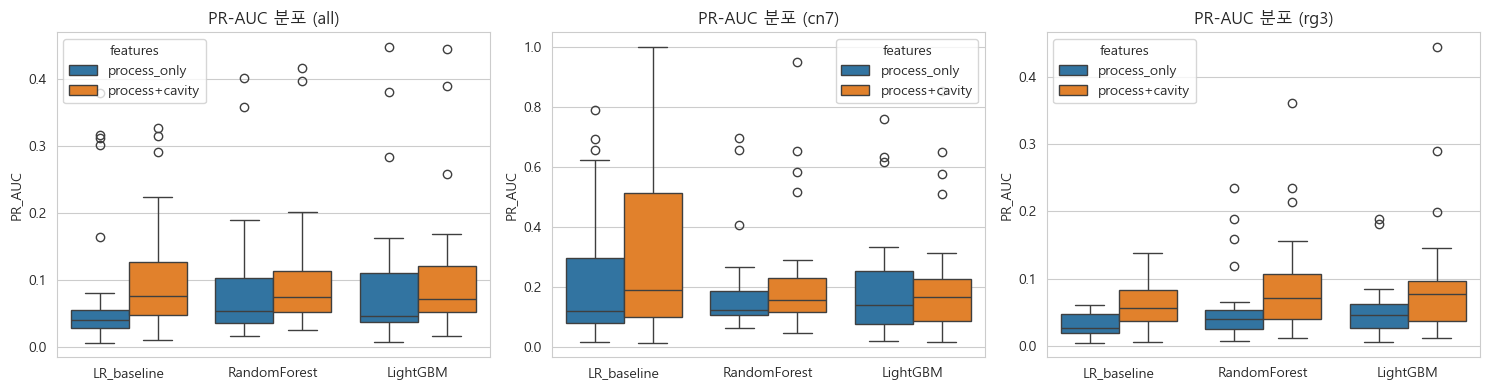

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, sc in zip(axes, ["all", "cn7", "rg3"]):
    sns.boxplot(data=cv[cv.scope == sc], x="model", y="PR_AUC", hue="features", ax=ax)
    ax.set_title(f"PR-AUC 분포 ({sc})"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

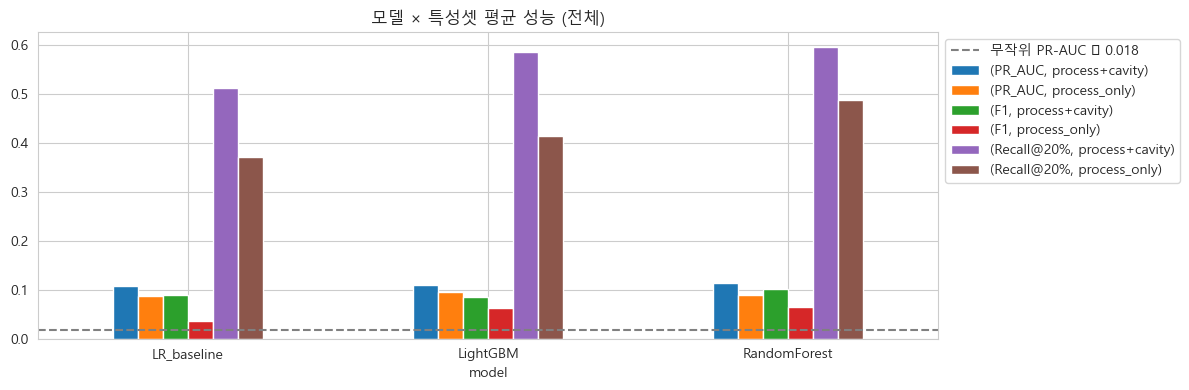

In [114]:
base = df[TARGET].mean()
tbl = cv[cv.scope == "all"].groupby(["model", "features"])[["PR_AUC", "F1", "Recall@20%"]].mean().unstack()
tbl.plot.bar(figsize=(12, 4), rot=0)
plt.axhline(base, ls="--", c="gray", label=f"무작위 PR-AUC ≈ {base:.3f}")
plt.title("모델 × 특성셋 평균 성능 (전체)"); plt.legend(bbox_to_anchor=(1, 1)); plt.tight_layout(); plt.show()

### 2-1. 최종모델 선정 및 테스트 성능

In [116]:
allscope = cv[cv.scope == "all"].groupby(["model", "features"])["PR_AUC"].mean()
BEST_MODEL, BEST_FS = allscope.idxmax()
USE_CAV = BEST_FS == "process+cavity"
print(f"최종모델: {BEST_MODEL} / {BEST_FS}  (CV PR-AUC {allscope.max():.3f})")

dev, test = holdout_split(df)
X_dev, X_test = feature_matrix(dev, USE_CAV), feature_matrix(test, USE_CAV)
y_dev, y_test = dev[TARGET].to_numpy(), test[TARGET].to_numpy()

model = get_models()[BEST_MODEL]
THR = best_threshold(y_dev, inner_oof(model, X_dev, y_dev, dev["group"].to_numpy(), SEED))
final = clone(model).fit(X_dev, y_dev)
p_test = final.predict_proba(X_test)[:, 1]

res = {"all": metrics(y_test, p_test, THR)}
for p in ["cn7", "rg3"]:
    m = test["product"].to_numpy() == p
    res[p] = metrics(y_test[m], p_test[m], THR)
print("임계값:", round(THR, 4))
pd.DataFrame(res).round(3)

최종모델: RandomForest / process+cavity  (CV PR-AUC 0.114)
임계값: 0.1406


,all,cn7,rg3
PR_AUC,0.381,0.750,0.057
ROC_AUC,0.846,0.991,0.542
F1,0.320,0.545,0.143
Precision,0.235,0.429,0.100
Recall,0.500,0.750,0.250
Recall@5%,0.625,1.000,0.250
Recall@10%,0.625,1.000,0.250
Recall@20%,0.625,1.000,0.250


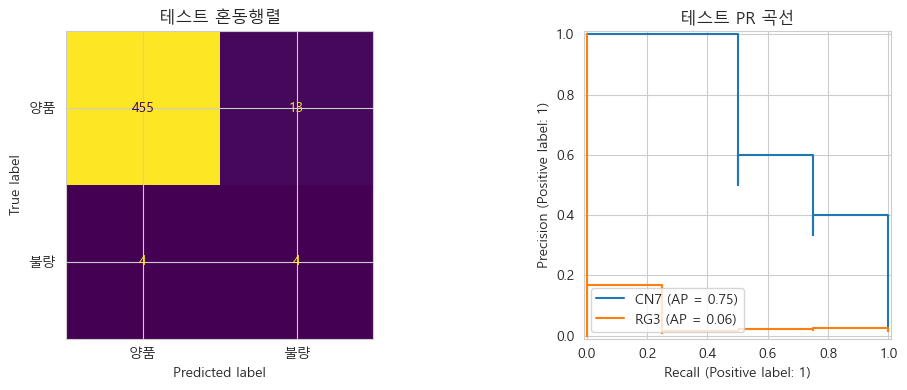

In [117]:
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= THR).astype(int), ax=ax[0],
                                        display_labels=["양품", "불량"], colorbar=False)
ax[0].set_title("테스트 혼동행렬")
for p in ["cn7", "rg3"]:
    m = test["product"].to_numpy() == p
    PrecisionRecallDisplay.from_predictions(y_test[m], p_test[m], ax=ax[1], name=p.upper())
ax[1].set_title("테스트 PR 곡선")
plt.tight_layout(); plt.show()

### 2-2. 확률 보정 (Calibration) 점검

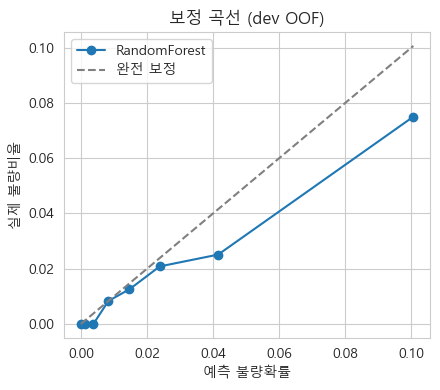

In [119]:
from sklearn.calibration import calibration_curve

oof = pd.read_csv(OUT_DIR / "oof_dev.csv")
frac, mean_p = calibration_curve(oof[TARGET], oof["oof_prob"], n_bins=8, strategy="quantile")
plt.figure(figsize=(4.5, 4))
plt.plot(mean_p, frac, "o-", label=BEST_MODEL)
plt.plot([0, mean_p.max()], [0, mean_p.max()], "--", c="gray", label="완전 보정")
plt.xlabel("예측 불량확률"); plt.ylabel("실제 불량비율"); plt.title("보정 곡선 (dev OOF)")
plt.legend(); plt.tight_layout(); plt.show()

## 3. 영향요인 및 오류분석

### 3-1. 주요 영향변수 (SHAP)

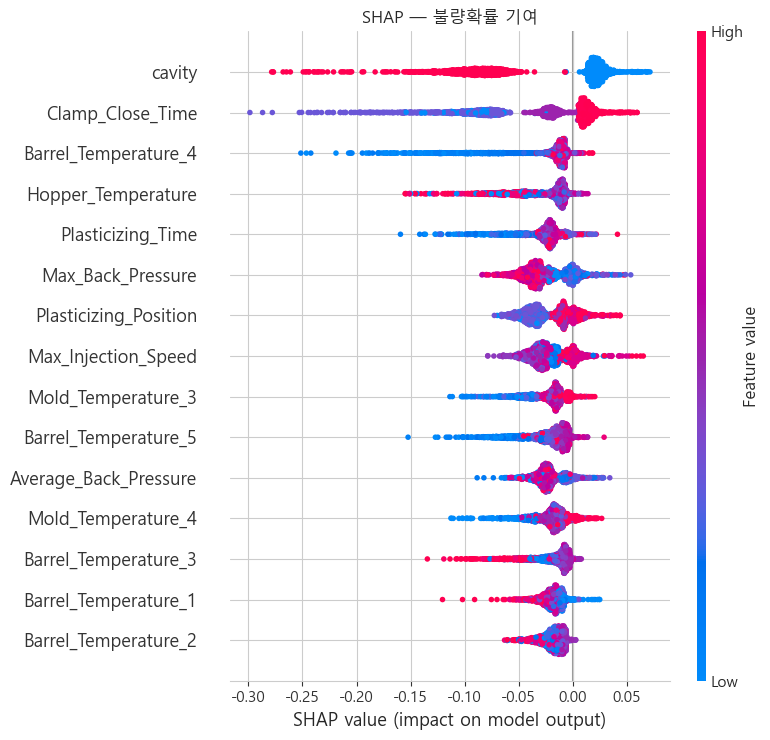

In [123]:
import shap

explainer = shap.TreeExplainer(final)
sv = explainer.shap_values(X_dev)
sv1 = sv[..., 1] if np.ndim(sv) == 3 else (sv[1] if isinstance(sv, list) else sv)   # 불량 클래스
shap.summary_plot(sv1, X_dev, max_display=15, show=False)
plt.title("SHAP — 불량확률 기여"); plt.tight_layout(); plt.show()

상위 변수: {'cavity': 0.0576, 'Clamp_Close_Time': 0.0466, 'Barrel_Temperature_4': 0.0317, 'Hopper_Temperature': 0.0301, 'Plasticizing_Time': 0.0291, 'Max_Back_Pressure': 0.0268, 'Plasticizing_Position': 0.0241, 'Max_Injection_Speed': 0.0231, 'Mold_Temperature_3': 0.023, 'Barrel_Temperature_5': 0.0227}


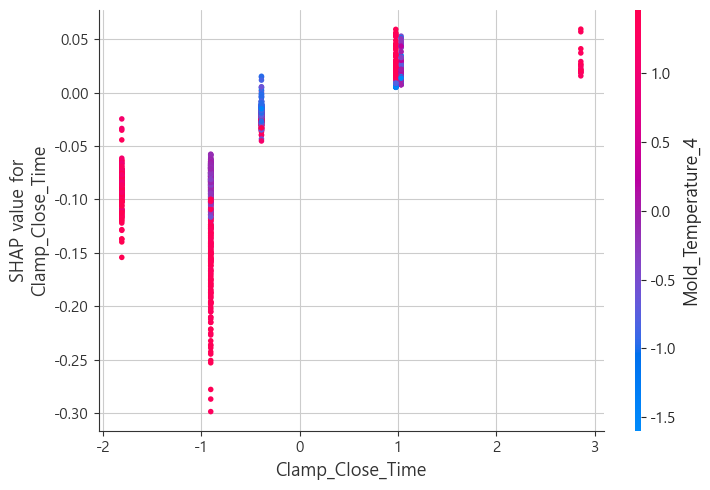

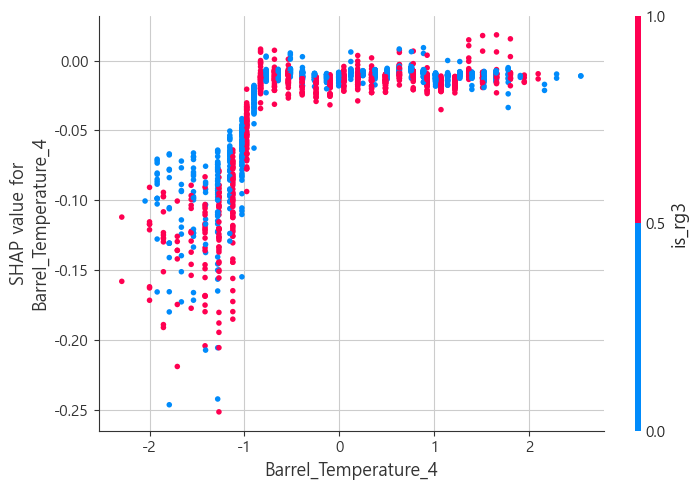

In [124]:
imp = pd.Series(np.abs(sv1).mean(0), index=X_dev.columns).sort_values(ascending=False)
TOP2 = [c for c in imp.index if c not in ("is_rg3", "cavity")][:2]
print("상위 변수:", imp.head(10).round(4).to_dict())
for c in TOP2:
    shap.dependence_plot(c, sv1, X_dev, interaction_index="auto", show=False)
    plt.tight_layout(); plt.show()

### 3-2. 변수 간 상호작용 — 상위 2개 변수 구간별 불량률

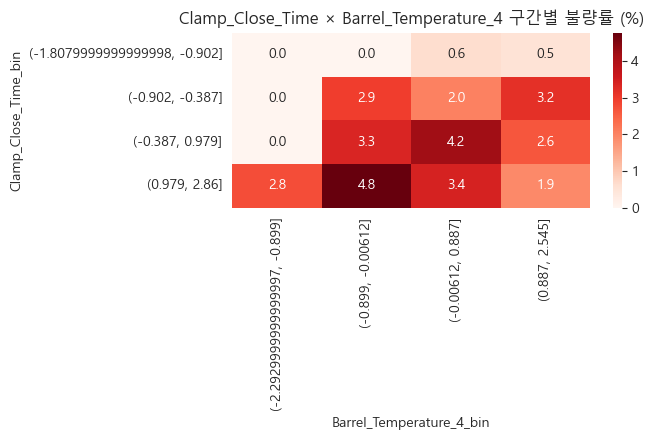

In [126]:
tmp = dev.copy()
for c in TOP2:
    tmp[c + "_bin"] = pd.qcut(tmp[c], 4, duplicates="drop")
pv = tmp.pivot_table(index=TOP2[0] + "_bin", columns=TOP2[1] + "_bin", values=TARGET, aggfunc="mean") * 100
plt.figure(figsize=(7, 4.5))
sns.heatmap(pv, annot=True, fmt=".1f", cmap="Reds")
plt.title(f"{TOP2[0]} × {TOP2[1]} 구간별 불량률 (%)"); plt.tight_layout(); plt.show()

### 3-3. FN(미탐지) · FP(오경보) 분석
dev OOF 예측 기준. FN = 불량을 양품으로, FP = 양품을 불량으로 판정.

In [129]:
oof["error"] = oof["error"].fillna("OK")
oof["type"] = np.select(
    [(oof[TARGET] == 1) & (oof.error == "OK"), oof.error == "FN", oof.error == "FP"],
    ["TP", "FN", "FP"], "TN")
display(pd.crosstab([oof["product"], oof["cavity"]], oof["type"]))

type            FN  FP   TN  TP
product cavity                 
cn7     0        8  11  492   2
        1        3   1  455   0
rg3     0       19  17  449   1
        1        1   0  458   0

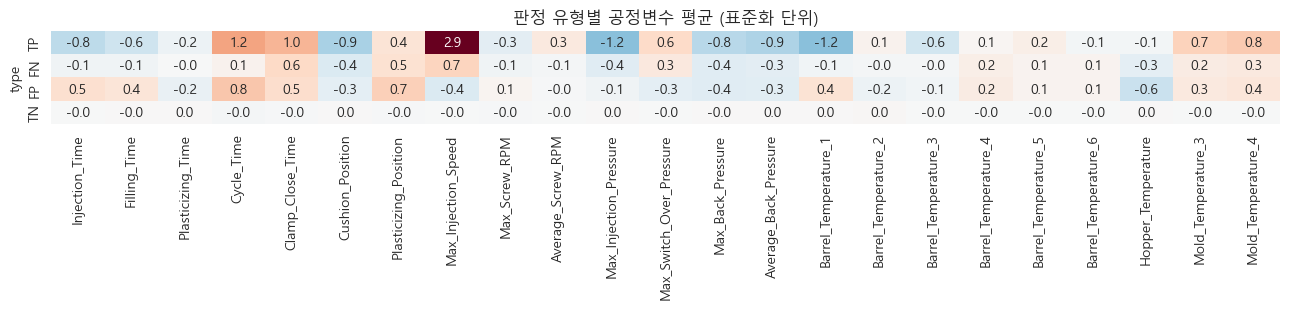

In [130]:
prof = oof.groupby("type")[use].mean().loc[["TP", "FN", "FP", "TN"]]
plt.figure(figsize=(13, 3.2))
sns.heatmap(prof, cmap="RdBu_r", center=0, annot=True, fmt=".1f", cbar=False)
plt.title("판정 유형별 공정변수 평균 (표준화 단위)"); plt.tight_layout(); plt.show()

In [131]:
# 오류가 집중되는 공정조건: 변수 구간별 FN / FP 비율
def error_rate_by_bin(col, q=4):
    b = pd.qcut(oof[col], q, duplicates="drop")
    g = oof.groupby(b)
    return pd.DataFrame({
        "n": g.size(),
        "불량 수": g[TARGET].sum(),
        "FN 비율(불량 중)": g.apply(lambda d: (d.type == "FN").sum() / max(1, d[TARGET].sum())),
        "FP 비율(양품 중)": g.apply(lambda d: (d.type == "FP").sum() / max(1, (d[TARGET] == 0).sum())),
    }).round(3)

for c in imp.index.drop(["is_rg3", "cavity"], errors="ignore")[:5]:
    print(f"■ {c}")
    display(error_rate_by_bin(c))

■ Clamp_Close_Time


,n,불량 수,FN 비율(불량 중),FP 비율(양품 중)
Clamp_Close_Time,,,,
"(-1.8079999999999998, -0.902]",670,2,1.000,0.001
"(-0.902, -0.387]",398,8,1.000,0.028
"(-0.387, 0.979]",434,11,0.818,0.024
"(0.979, 2.86]",415,13,0.923,0.017


■ Barrel_Temperature_4


,n,불량 수,FN 비율(불량 중),FP 비율(양품 중)
Barrel_Temperature_4,,,,
"(-2.2929999999999997, -0.899]",499,3,1.000,0.000
"(-0.899, -0.00612]",466,11,0.909,0.029
"(-0.00612, 0.887]",489,12,0.833,0.015
"(0.887, 2.545]",463,8,1.000,0.020


■ Hopper_Temperature


,n,불량 수,FN 비율(불량 중),FP 비율(양품 중)
Hopper_Temperature,,,,
"(-3.072, -0.732]",485,11,0.909,0.034
"(-0.732, 0.0324]",497,9,0.889,0.010
"(0.0324, 0.793]",475,11,0.909,0.017
"(0.793, 2.55]",460,3,1.000,0.000


■ Plasticizing_Time


,n,불량 수,FN 비율(불량 중),FP 비율(양품 중)
Plasticizing_Time,,,,
"(-2.513, -0.491]",485,8,1.000,0.023
"(-0.491, -0.0425]",533,15,0.867,0.019
"(-0.0425, 0.307]",464,1,0.000,0.002
"(0.307, 20.038]",435,10,1.000,0.016


■ Max_Back_Pressure


,n,불량 수,FN 비율(불량 중),FP 비율(양품 중)
Max_Back_Pressure,,,,
"(-2.677, -0.741]",487,14,0.929,0.025
"(-0.741, 0.225]",554,11,0.818,0.022
"(0.225, 0.843]",489,3,1.000,0.000
"(0.843, 2.092]",387,6,1.000,0.013


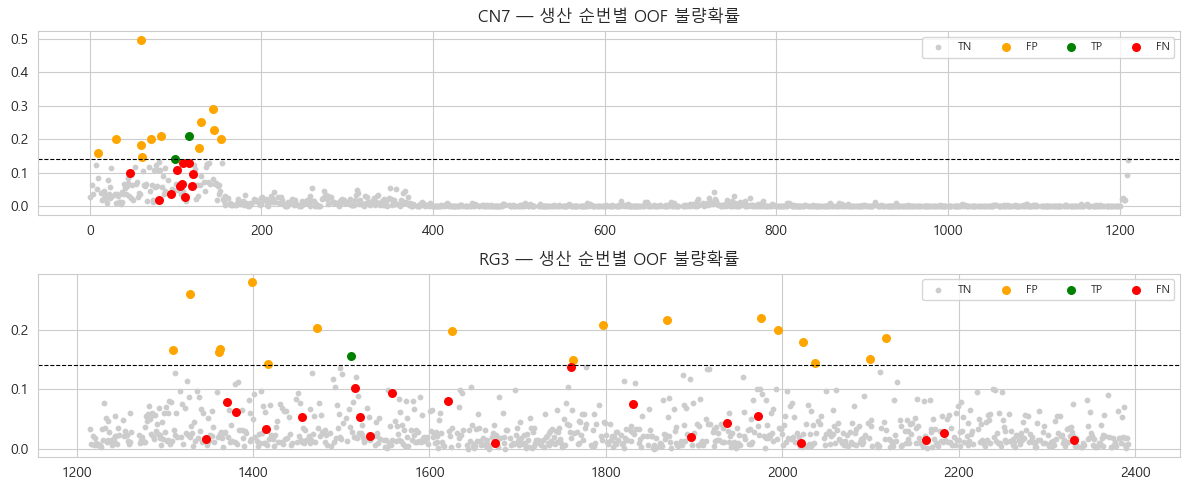

In [132]:
# 생산 순번에 따른 예측확률 — 오류가 특정 시기에 몰리는지
fig, axes = plt.subplots(2, 1, figsize=(12, 5))
for ax, (p, d) in zip(axes, oof.groupby("product")):
    for t, col in [("TN", "#cccccc"), ("FP", "orange"), ("TP", "green"), ("FN", "red")]:
        s = d[d.type == t]
        ax.scatter(s[INDEX_COL], s["oof_prob"], s=10 if t == "TN" else 30, c=col, label=t)
    ax.axhline(THR, ls="--", c="k", lw=.8)
    ax.set_title(f"{p.upper()} — 생산 순번별 OOF 불량확률"); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

## 4. 현장 활용방안 — 검사 우선순위
예측 불량확률 순으로 검사할 때, 검사 비율 대비 불량 포착률(누적 Recall)을 무작위 검사와 비교한다.

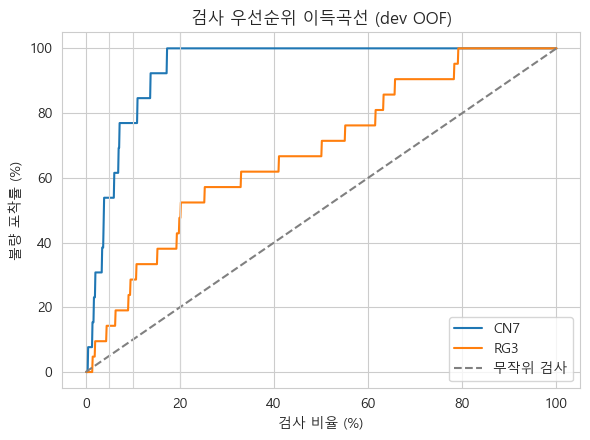

In [134]:
def gain_curve(y, p):
    order = np.argsort(-p)
    return np.arange(1, len(y) + 1) / len(y), np.cumsum(y[order]) / y.sum()

plt.figure(figsize=(6, 4.5))
for p, d in oof.groupby("product"):
    x, r = gain_curve(d[TARGET].to_numpy(), d["oof_prob"].to_numpy())
    plt.plot(x * 100, r * 100, label=p.upper())
plt.plot([0, 100], [0, 100], "--", c="gray", label="무작위 검사")
for k in (5, 10, 20):
    plt.axvline(k, c="lightgray", lw=.8)
plt.xlabel("검사 비율 (%)"); plt.ylabel("불량 포착률 (%)"); plt.title("검사 우선순위 이득곡선 (dev OOF)")
plt.legend(); plt.tight_layout(); plt.show()

In [135]:
rows = []
for p, d in oof.groupby("product"):
    y, s = d[TARGET].to_numpy(), d["oof_prob"].to_numpy()
    for k in (0.05, 0.10, 0.20, 0.30):
        n = int(np.ceil(len(y) * k)); top = np.argsort(-s)[:n]
        rows.append({"product": p, "검사비율": f"{int(k*100)}%", "검사 수": n,
                     "포착 불량": int(y[top].sum()), "전체 불량": int(y.sum()),
                     "포착률": round(y[top].sum() / y.sum(), 3),
                     "무작위 대비 배수": round((y[top].sum() / y.sum()) / k, 2)})
pd.DataFrame(rows)

,product,검사비율,검사 수,포착 불량,전체 불량,포착률,무작위 대비 배수
0,cn7,5%,49,7,13,0.538,10.77
1,cn7,10%,98,10,13,0.769,7.69
2,cn7,20%,195,13,13,1.000,5.00
3,cn7,30%,292,13,13,1.000,3.33
4,rg3,5%,48,3,21,0.143,2.86
5,rg3,10%,95,6,21,0.286,2.86
6,rg3,20%,189,10,21,0.476,2.38
7,rg3,30%,284,12,21,0.571,1.90


In [136]:
# 위험등급 제안: 확률 분위 기반 3단계
q_hi, q_mid = np.quantile(oof["oof_prob"], [0.90, 0.70])
oof["risk"] = pd.cut(oof["oof_prob"], [-np.inf, q_mid, q_hi, np.inf], labels=["정상", "주의", "위험"])
display(oof.groupby("risk", observed=True).agg(n=(TARGET, "size"), 불량=(TARGET, "sum"),
                                               불량률=(TARGET, "mean")).round(3))
print(f"경계값 — 주의 ≥ {q_mid:.3f}, 위험 ≥ {q_hi:.3f}")

,n,불량,불량률
risk,,,
정상,1342,8,0.006
주의,383,11,0.029
위험,192,15,0.078


경계값 — 주의 ≥ 0.025, 위험 ≥ 0.065


## 5. 테스트 예측결과 저장

In [139]:
pred = test[[INDEX_COL, "product", "shot_id", "cavity", TARGET]].copy()
pred["fail_prob"] = p_test
pred["pred"] = (p_test >= THR).astype(int)
pred["inspect_rank"] = pred["fail_prob"].rank(ascending=False, method="first").astype(int)
pred = pred.sort_values("inspect_rank")
pred.to_csv(OUT_DIR / "test_predictions.csv", index=False, encoding="utf-8-sig")
pred.head(15)

,Unnamed: 0,product,shot_id,cavity,PassOrFail,fail_prob,pred,inspect_rank
22,117,cn7,58,0,1,0.530060,1,1
23,118,cn7,58,1,1,0.481253,1,2
316,1619,rg3,205,0,0,0.267205,1,3
24,131,cn7,65,0,0,0.215239,1,4
16,97,cn7,48,0,0,0.215020,1,5
308,1559,rg3,175,0,0,0.203649,1,6
302,1535,rg3,163,0,0,0.195350,1,7
18,103,cn7,51,0,1,0.195272,1,8
355,1825,rg3,313,0,0,0.187758,1,9
2,5,cn7,2,0,0,0.177467,1,10
